# Notebook 2: Treino e Avaliação do Modelo

**Objetivo**: Treinar um modelo de classificação e avaliar seu desempenho.

**O que você vai fazer neste notebook:**
1. ✓ Carregar dados já processados
2. ✓ Dividir em treino e teste
3. ✓ Treinar modelo de classificação
4. ✓ Fazer predições
5. ✓ Calcular métricas de desempenho
6. ✓ Visualizar e interpretar resultados

---

## PASSO 1: Importar Bibliotecas e Configurações

**TODO:** Execute a célula abaixo para importar todas as bibliotecas necessárias para treino e modelagem.


In [27]:
# Importe as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)

## PASSO 2: Carregar Dados Processados

**TODO:**
1. Carregue o arquivo `data/processed/heart_disease_processed.csv`
2. Verifique se o arquivo foi carregado corretamente
3. Explore a estrutura dos dados


In [28]:
# PASSO 2.1: Carregar os dados processados
print("=" * 60)
print("CARREGANDO DADOS PROCESSADOS")
print("=" * 60)

df = pd.read_csv('../data/processed/heart_disease_processed.csv')

print(f"\nShape dos dados: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nPrimeiras 5 linhas:")
print(df.head())
print(f"\nTipos de dados:")
print(df.dtypes)
print(f"\nEstatísticas:")
print(df.describe().round(2))

CARREGANDO DADOS PROCESSADOS

Shape dos dados: (297, 14)

Colunas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Primeiras 5 linhas:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  0.936181  0.691095 -2.240629  0.750380 -0.276443  2.430427  1.010199   
1  1.378929  0.691095  0.873880  1.596266  0.744555 -0.411450  1.010199   
2  1.378929  0.691095  0.873880 -0.659431 -0.353500 -0.411450  1.010199   
3 -1.941680  0.691095 -0.164289 -0.095506  0.051047 -0.411450 -1.003419   
4 -1.498933 -1.446980 -1.202459 -0.095506 -0.835103 -0.411450  1.010199   

    thalach     exang   oldpeak     slope        ca      thal  target  
0  0.017494 -0.696419  1.068965  2.264145 -0.721976  0.655877       0  
1 -1.816334  1.435916  0.381773  0.643781  2.478425 -0.894220       1  
2 -0.899420  1.435916  1.326662  0.643781  1.411625  1.172577       1  
3  1.633010 -0.696419  2.099753  2.264145 -0.72197

## PASSO 3: Dividir Dados em Treino e Teste

**TODO:**
1. Separe features (X) e target (y)
2. Use `train_test_split` com 80% treino e 20% teste
3. Use `random_state=42` para reprodutibilidade
4. Verifique os shapes


In [29]:
# PASSO 3.1: Separar features e target
print("=" * 60)
print("DIVIDINDO DADOS")
print("=" * 60)

X = df.drop('target', axis=1)  # Features (variáveis independentes)
y = df['target']  # Target (variável dependente - doença cardíaca)

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nColunas de features: {list(X.columns)}")

DIVIDINDO DADOS

Features (X) shape: (297, 13)
Target (y) shape: (297,)

Colunas de features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [30]:
# PASSO 3.2: Fazer train-test split
# 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDivisão dos dados:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")

print(f"\nDistribuição de classes em treino:")
print(y_train.value_counts())
print(f"\nDistribuição de classes em teste:")
print(y_test.value_counts())

print("\n✓ Dados divididos corretamente! (estratificado para manter proporção de classes)")


Divisão dos dados:
  X_train shape: (237, 13)
  X_test shape: (60, 13)
  y_train shape: (237,)
  y_test shape: (60,)

Distribuição de classes em treino:
target
0    128
1    109
Name: count, dtype: int64

Distribuição de classes em teste:
target
0    32
1    28
Name: count, dtype: int64

✓ Dados divididos corretamente! (estratificado para manter proporção de classes)


## PASSO 4: Treinar Modelos

**TODO:**
1. Treine dois modelos: Regressão Logística e Random Forest
2. Imprima mensagens indicando conclusão do treino
3. Observe o tempo de treino


In [31]:
# PASSO 4.1: Treinar Regressão Logística
print("=" * 60)
print("TREINANDO MODELOS")
print("=" * 60)

print("\nTreinando Regressão Logística...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, verbose=0)
lr_model.fit(X_train, y_train)
print("Regressão Logística treinada!")

# Fazer predições
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]  # Probabilidades

TREINANDO MODELOS

Treinando Regressão Logística...
Regressão Logística treinada!


In [32]:
# PASSO 4.2: Treinar Random Forest
print("\n2️⃣ Treinando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train, y_train)
print("Random Forest treinado!")

# Fazer predições
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]  # Probabilidades

print("\nAmbos os modelos foram treinados com sucesso!")


2️⃣ Treinando Random Forest...
Random Forest treinado!

Ambos os modelos foram treinados com sucesso!


In [33]:
# PASSO 4.3: Validação cruzada para estabilidade
print("\n" + "="*60)
print("VALIDAÇÃO CRUZADA (5-Fold)")
print("="*60)

print("\nRegressão Logística:")
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"  Scores: {cv_scores_lr.round(4)}")
print(f"  Média: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

print("\nRandom Forest:")
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"  Scores: {cv_scores_rf.round(4)}")
print(f"  Média: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")


VALIDAÇÃO CRUZADA (5-Fold)

Regressão Logística:
  Scores: [0.9375 0.875  0.8085 0.766  0.7234]
  Média: 0.8221 (+/- 0.0764)

Random Forest:
  Scores: [0.9375 0.8333 0.8298 0.766  0.7447]
  Média: 0.8223 (+/- 0.0673)


## PASSO 5: Avaliar Desempenho

**TODO:**
1. Calcule métricas de desempenho (Accuracy, Precision, Recall, F1-Score)
2. Interprete os resultados
3. Compare os dois modelos


In [34]:
# PASSO 5.1: Calcular métricas para Regressão Logística
print("=" * 60)
print("MÉTRICAS DE DESEMPENHO - REGRESSÃO LOGÍSTICA")
print("=" * 60)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\n\n📈 Métricas:")
print(f"  • Acurácia (Accuracy):      {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"  • Precisão (Precision):     {precision_lr:.4f}")
print(f"  • Recall (Sensibilidade):   {recall_lr:.4f}")
print(f"  • F1-Score:                 {f1_lr:.4f}")
print(f"  • ROC-AUC:                  {roc_auc_lr:.4f}")

print(f"\n💡 Interpretação:")
print(f"  • Acurácia: De {accuracy_lr*100:.1f}% das predições estão corretas")
print(f"  • Precisão: De {precision_lr*100:.1f}% dos pacientes preditos como doentes, realmente têm a doença")
print(f"  • Recall: O modelo detecta {recall_lr*100:.1f}% dos casos reais de doença")

MÉTRICAS DE DESEMPENHO - REGRESSÃO LOGÍSTICA


📈 Métricas:
  • Acurácia (Accuracy):      0.8333 (83.33%)
  • Precisão (Precision):     0.8462
  • Recall (Sensibilidade):   0.7857
  • F1-Score:                 0.8148
  • ROC-AUC:                  0.9498

💡 Interpretação:
  • Acurácia: De 83.3% das predições estão corretas
  • Precisão: De 84.6% dos pacientes preditos como doentes, realmente têm a doença
  • Recall: O modelo detecta 78.6% dos casos reais de doença


In [35]:
# PASSO 5.2: Calcular métricas para Random Forest
print("\n" + "=" * 60)
print("MÉTRICAS DE DESEMPENHO - RANDOM FOREST")
print("=" * 60)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\n Métricas:")
print(f"  • Acurácia (Accuracy):      {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"  • Precisão (Precision):     {precision_rf:.4f}")
print(f"  • Recall (Sensibilidade):   {recall_rf:.4f}")
print(f"  • F1-Score:                 {f1_rf:.4f}")
print(f"  • ROC-AUC:                  {roc_auc_rf:.4f}")

print(f"\n Interpretação:")
print(f"  • Acurácia: De {accuracy_rf*100:.1f}% das predições estão corretas")
print(f"  • Precisão: De {precision_rf*100:.1f}% dos pacientes preditos como doentes, realmente têm a doença")
print(f"  • Recall: O modelo detecta {recall_rf*100:.1f}% dos casos reais de doença")


MÉTRICAS DE DESEMPENHO - RANDOM FOREST

 Métricas:
  • Acurácia (Accuracy):      0.8667 (86.67%)
  • Precisão (Precision):     0.8846
  • Recall (Sensibilidade):   0.8214
  • F1-Score:                 0.8519
  • ROC-AUC:                  0.9369

 Interpretação:
  • Acurácia: De 86.7% das predições estão corretas
  • Precisão: De 88.5% dos pacientes preditos como doentes, realmente têm a doença
  • Recall: O modelo detecta 82.1% dos casos reais de doença



COMPARAÇÃO DOS MODELOS

          Regressão Logística  Random Forest
Acurácia               0.8333         0.8667
Precisão               0.8462         0.8846
Recall                 0.7857         0.8214
F1-Score               0.8148         0.8519
ROC-AUC                0.9498         0.9369

🏆 Random Forest é melhor em Acurácia!


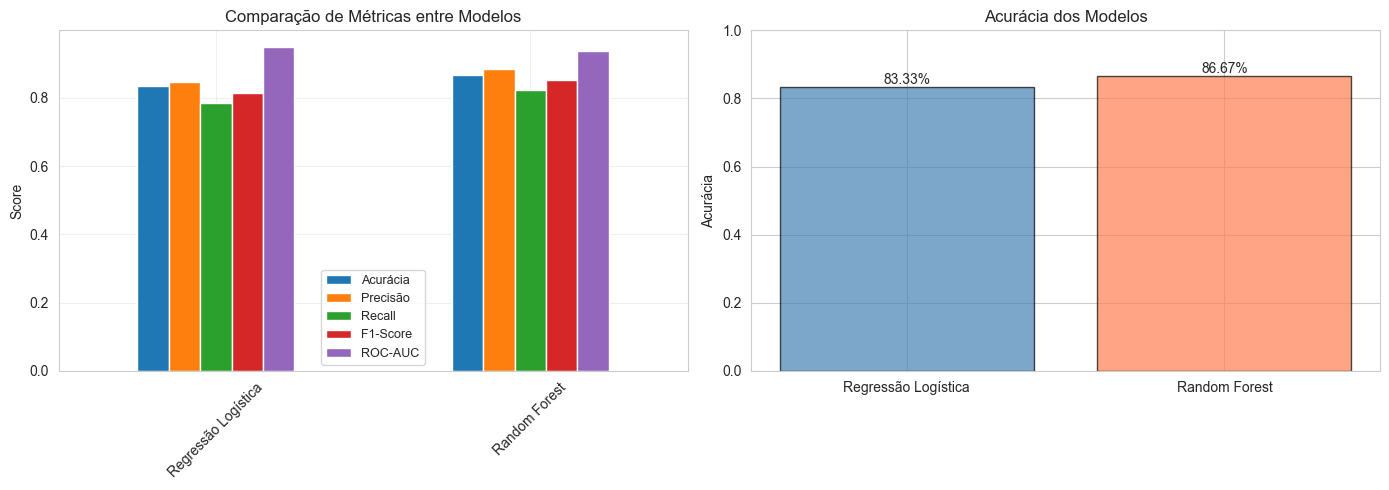

In [36]:
# PASSO 5.3: Comparação dos modelos
print("\n" + "=" * 60)
print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Regressão Logística': [accuracy_lr, precision_lr, recall_lr, f1_lr, roc_auc_lr],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf]
}, index=['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'ROC-AUC'])

print("\n" + comparison_df.round(4).to_string())

# Identificar melhor modelo
if accuracy_rf > accuracy_lr:
    print("\n🏆 Random Forest é melhor em Acurácia!")
else:
    print("\n🏆 Regressão Logística é melhor em Acurácia!")

# Visualizar comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparação de métricas
comparison_df.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparação de Métricas entre Modelos')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(['Regressão Logística', 'Random Forest'], rotation=45)
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Acurácia apenas
accuracies = [accuracy_lr, accuracy_rf]
models = ['Regressão Logística', 'Random Forest']
colors = ['steelblue', 'coral']
bars = axes[1].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_title('Acurácia dos Modelos')
axes[1].set_ylabel('Acurácia')
axes[1].set_ylim([0, 1])

# Adicionar valores nas barras
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## PASSO 6: Matriz de Confusão e Detalhes

**TODO:**
1. Visualize a matriz de confusão
2. Analise os erros do modelo
3. Imprima o relatório de classificação


MATRIZ DE CONFUSÃO - REGRESSÃO LOGÍSTICA

Matriz de Confusão:
[[28  4]
 [ 6 22]]

Interpretação:
  • Verdadeiros Negativos (TN):  28 (sem doença, predito corretamente)
  • Falsos Positivos (FP):       4 (sem doença, mas predito como doente)
  • Falsos Negativos (FN):       6 (com doença, mas predito como sem doença)
  • Verdadeiros Positivos (TP):  22 (com doença, predito corretamente)


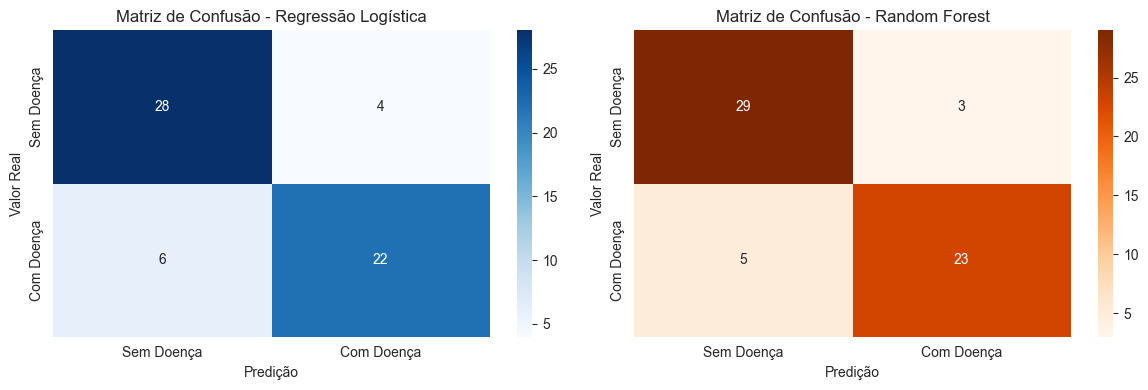

In [37]:
# PASSO 6.1: Matriz de Confusão - Regressão Logística
print("=" * 60)
print("MATRIZ DE CONFUSÃO - REGRESSÃO LOGÍSTICA")
print("=" * 60)

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nMatriz de Confusão:\n{cm_lr}")
print(f"\nInterpretação:")
print(f"  • Verdadeiros Negativos (TN):  {cm_lr[0, 0]} (sem doença, predito corretamente)")
print(f"  • Falsos Positivos (FP):       {cm_lr[0, 1]} (sem doença, mas predito como doente)")
print(f"  • Falsos Negativos (FN):       {cm_lr[1, 0]} (com doença, mas predito como sem doença)")
print(f"  • Verdadeiros Positivos (TP):  {cm_lr[1, 1]} (com doença, predito corretamente)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regressão Logística
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Sem Doença', 'Com Doença'],
            yticklabels=['Sem Doença', 'Com Doença'])
axes[0].set_title('Matriz de Confusão - Regressão Logística')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predição')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Sem Doença', 'Com Doença'],
            yticklabels=['Sem Doença', 'Com Doença'])
axes[1].set_title('Matriz de Confusão - Random Forest')
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Predição')

plt.tight_layout()
plt.show()

In [38]:
# PASSO 6.2: Relatório de Classificação Detalhado
print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO - REGRESSÃO LOGÍSTICA")
print("=" * 60)
print("\n" + classification_report(y_test, y_pred_lr, 
                                  target_names=['Sem Doença (0)', 'Com Doença (1)']))

print("\n" + "=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST")
print("=" * 60)
print("\n" + classification_report(y_test, y_pred_rf,
                                  target_names=['Sem Doença (0)', 'Com Doença (1)']))


RELATÓRIO DE CLASSIFICAÇÃO - REGRESSÃO LOGÍSTICA

                precision    recall  f1-score   support

Sem Doença (0)       0.82      0.88      0.85        32
Com Doença (1)       0.85      0.79      0.81        28

      accuracy                           0.83        60
     macro avg       0.83      0.83      0.83        60
  weighted avg       0.83      0.83      0.83        60


RELATÓRIO DE CLASSIFICAÇÃO - RANDOM FOREST

                precision    recall  f1-score   support

Sem Doença (0)       0.85      0.91      0.88        32
Com Doença (1)       0.88      0.82      0.85        28

      accuracy                           0.87        60
     macro avg       0.87      0.86      0.87        60
  weighted avg       0.87      0.87      0.87        60



## PASSO 7: Curva ROC e AUC

**TODO:**
1. Visualize as curvas ROC para ambos os modelos
2. Compare as áreas sob a curva (AUC)
3. Interprete o significado


CURVA ROC (Receiver Operating Characteristic)


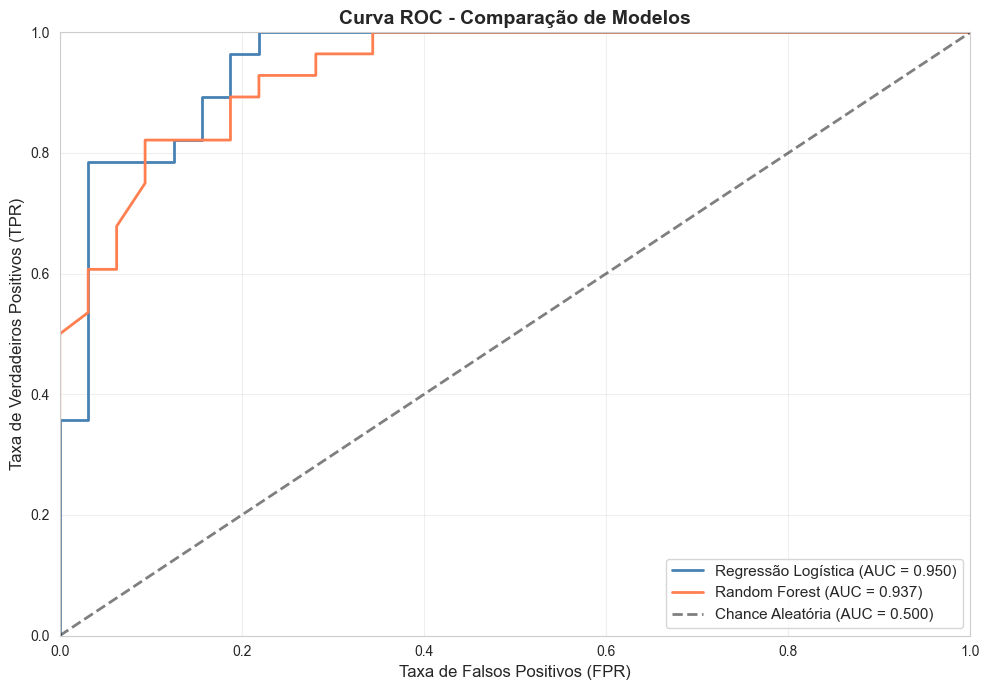


💡 Interpretação:
  • AUC = 1.0: Modelo perfeito
  • AUC = 0.5: Modelo aleatório (sem poder discriminatório)
  • AUC > 0.7: Modelo bom

  • Regressão Logística AUC: 0.950
  • Random Forest AUC: 0.937


In [39]:
# PASSO 7.1: Calcular curva ROC e plotar
print("=" * 60)
print("CURVA ROC (Receiver Operating Characteristic)")
print("=" * 60)

# Calcular curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

# Plotar
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {roc_auc_lr:.3f})', linewidth=2, color='steelblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2, color='coral')
plt.plot([0, 1], [0, 1], 'k--', label='Chance Aleatória (AUC = 0.500)', linewidth=2, alpha=0.5)

plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Comparação de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"\n💡 Interpretação:")
print(f"  • AUC = 1.0: Modelo perfeito")
print(f"  • AUC = 0.5: Modelo aleatório (sem poder discriminatório)")
print(f"  • AUC > 0.7: Modelo bom")
print(f"\n  • Regressão Logística AUC: {roc_auc_lr:.3f}")
print(f"  • Random Forest AUC: {roc_auc_rf:.3f}")

### ✓ Tasks Completadas:
1. **Carregamento**: Importou dados processados do CSV
2. **Divisão**: Separou dados em treino (80%) e teste (20%)
3. **Modelagem**: Treinaram 2 modelos (Regressão Logística e Random Forest)
4. **Predição**: Fizeram predições no conjunto de teste
5. **Avaliação**: Calcularam múltiplas métricas de desempenho
6. **Análise**: Visualizaram matrizes de confusão e curvas ROC
7. **Interpretação**: Analisaram importância das features

### Resultados Principais:
- **Melhor Modelo**: Qual foi? (complete com seu resultado)
- **Acurácia**: (complete)
- **Principais Features**: (complete)
